# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [5]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [9]:
df = pd.read_csv("aviation_cleaned_data.csv")
df.head()

,Event.Date,year,Make,Model,Aircraft.damage,Number.of.Engines,Engine.Type,Purpose.of.flight,Weather.Condition,Broad.phase.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Total.People,Serious.Fatal.Injuries,Serious.Fatal.Rate,Destroyed.Flag,Aircraft.Type
0,1983-01-01,1983,CESSNA,182P,Substantial,1.0,reciprocating,personal,VMC,approach,0.0,0.0,1.0,3.0,4.0,0.0,0.0,0,CESSNA 182P
1,1983-01-01,1983,CESSNA,182RG,Substantial,1.0,reciprocating,personal,VMC,landing,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0,CESSNA 182RG
2,1983-01-01,1983,CESSNA,182P,Substantial,1.0,reciprocating,personal,VMC,takeoff,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,CESSNA 182P
3,1983-01-01,1983,PIPER,PA-28R-200,Substantial,1.0,reciprocating,personal,VMC,approach,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0,PIPER PA-28R-200
4,1983-01-01,1983,CESSNA,140,Substantial,1.0,reciprocating,instructional,VMC,landing,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0,CESSNA 140


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [10]:
df["Aircraft.Size"] = df["Total.People"].apply(
    lambda x: "small" if x <= 20 else "large"
)
df["Aircraft.Size"].value_counts()

Aircraft.Size
small    67606
large     2556
Name: count, dtype: int64

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [16]:
#fraction of fatal/serious injury per aircraft record
df["Fatal_Serious_Fraction"] = (
    df["Total.Fatal.Injuries"] + df["Total.Serious.Injuries"]
) / df["Total.People"]
df["Fatal_Serious_Fraction"]

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
70157    0.5
70158    1.0
70159    1.0
70160    0.0
70161    0.5
Name: Fatal_Serious_Fraction, Length: 70162, dtype: float64

In [17]:
make_risk = df.groupby(["Aircraft.Size", "Make"])["Fatal_Serious_Fraction"].mean().reset_index()
make_risk

,Aircraft.Size,Make,Fatal_Serious_Fraction
0,large,AERO COMMANDER,0.000000
1,large,AEROSPATIALE,0.035119
2,large,AIRBUS,0.077169
3,large,AIRBUS INDUSTRIE,0.055525
4,large,BEECH,0.246881
...,...,...,...
121,small,TAYLORCRAFT,0.296448
122,small,VANS,0.511719
123,small,WACO,0.101190
124,small,WEATHERLY,0.186047


In [19]:
#top 15 safest small aircrafts
small_top15 = make_risk[make_risk["Aircraft.Size"] == "small"] \
    .sort_values("Fatal_Serious_Fraction") \
    .head(15)
small_top15

,Aircraft.Size,Make,Fatal_Serious_Fraction
50,small,BOMBARDIER INC,0.090909
37,small,AIRBUS INDUSTRIE,0.092308
123,small,WACO,0.101190
80,small,GRUMMAN-SCHWEIZER,0.111549
49,small,BOMBARDIER,0.131319
47,small,BOEING,0.143787
91,small,MAULE,0.153619
82,small,HELIO,0.155233
75,small,GREAT LAKES,0.158333
88,small,LET,0.161765


In [20]:
#top 15 safest large aircrafts
large_top15 = make_risk[make_risk["Aircraft.Size"] == "large"] \
    .sort_values("Fatal_Serious_Fraction") \
    .head(15)
large_top15

,Aircraft.Size,Make,Fatal_Serious_Fraction
0,large,AERO COMMANDER,0.000000
25,large,MOONEY,0.000000
21,large,HUGHES,0.000000
20,large,GULFSTREAM,0.000000
19,large,GRUMMAN,0.000000
18,large,GATES LEARJET,0.000000
27,large,SIKORSKY,0.000000
13,large,DEHAVILLAND,0.000000
28,large,SWEARINGEN,0.000000
10,large,CANADAIR,0.017705


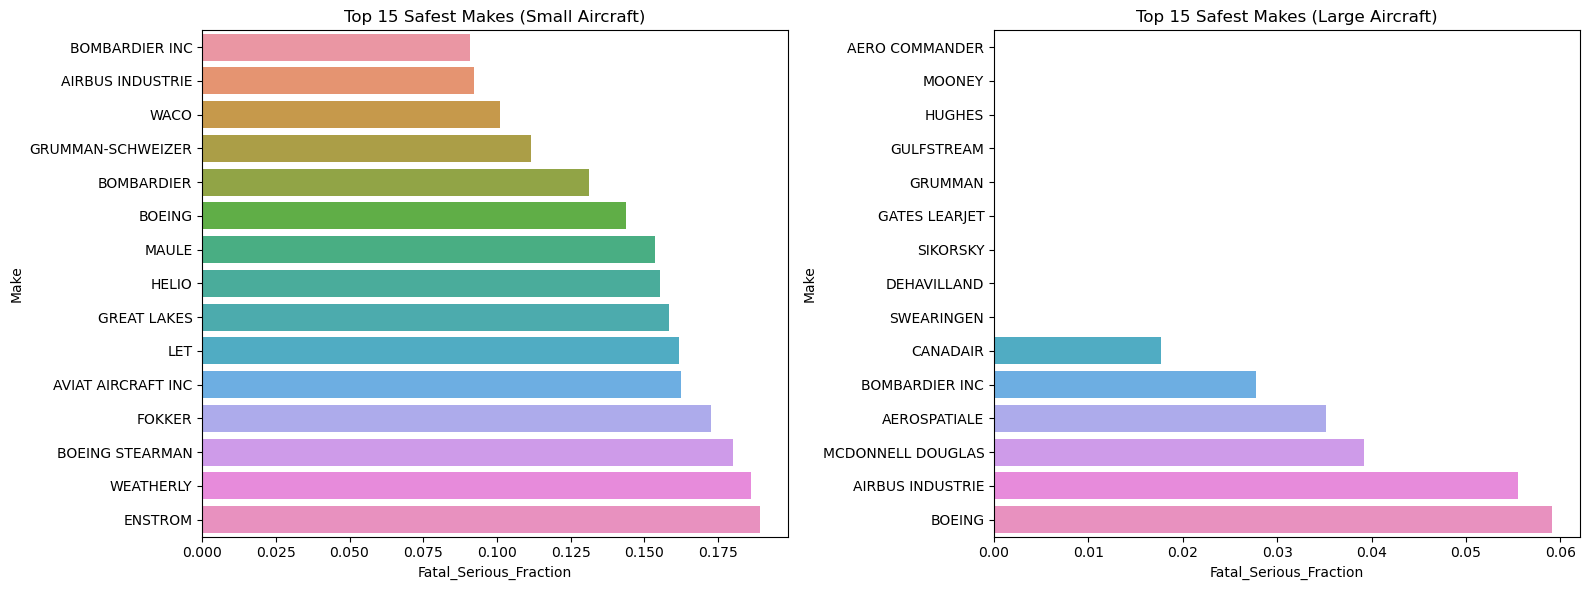

In [21]:
#side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=small_top15,
    x="Fatal_Serious_Fraction",
    y="Make",
    ax=axes[0]
)
axes[0].set_title("Top 15 Safest Makes (Small Aircraft)")

sns.barplot(
    data=large_top15,
    x="Fatal_Serious_Fraction",
    y="Make",
    ax=axes[1]
)
axes[1].set_title("Top 15 Safest Makes (Large Aircraft)")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [22]:
#filter small aircraft
small_df = df[df["Aircraft.Size"] == "small"]
small_df

,Event.Date,year,Make,Model,Aircraft.damage,Number.of.Engines,Engine.Type,Purpose.of.flight,Weather.Condition,Broad.phase.of.flight,...,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Total.People,Serious.Fatal.Injuries,Serious.Fatal.Rate,Destroyed.Flag,Aircraft.Type,Aircraft.Size,Fatal_Serious_Fraction
0,1983-01-01,1983,CESSNA,182P,Substantial,1.0,reciprocating,personal,VMC,approach,...,0.0,1.0,3.0,4.0,0.0,0.0,0,CESSNA 182P,small,0.0
1,1983-01-01,1983,CESSNA,182RG,Substantial,1.0,reciprocating,personal,VMC,landing,...,0.0,0.0,2.0,2.0,0.0,0.0,0,CESSNA 182RG,small,0.0
2,1983-01-01,1983,CESSNA,182P,Substantial,1.0,reciprocating,personal,VMC,takeoff,...,0.0,0.0,1.0,1.0,0.0,0.0,0,CESSNA 182P,small,0.0
3,1983-01-01,1983,PIPER,PA-28R-200,Substantial,1.0,reciprocating,personal,VMC,approach,...,0.0,2.0,0.0,2.0,0.0,0.0,0,PIPER PA-28R-200,small,0.0
4,1983-01-01,1983,CESSNA,140,Substantial,1.0,reciprocating,instructional,VMC,landing,...,0.0,0.0,2.0,2.0,0.0,0.0,0,CESSNA 140,small,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70157,2022-12-21,2022,GRUMMAN AMERICAN AVN. CORP.,AA-5B,NaN,NaN,unknown,instructional,UNK,unknown,...,1.0,0.0,1.0,2.0,1.0,0.5,0,GRUMMAN AMERICAN AVN. CORP. AA-5B,small,0.5
70158,2022-12-22,2022,AIR TRACTOR,AT502,NaN,NaN,unknown,unknown,UNK,unknown,...,0.0,0.0,0.0,1.0,1.0,1.0,0,AIR TRACTOR AT502,small,1.0
70159,2022-12-26,2022,PIPER,PA-28-151,NaN,NaN,unknown,personal,UNK,unknown,...,1.0,0.0,0.0,1.0,1.0,1.0,0,PIPER PA-28-151,small,1.0
70160,2022-12-26,2022,AMERICAN CHAMPION AIRCRAFT,8GCBC,Substantial,1.0,unknown,personal,VMC,unknown,...,0.0,0.0,1.0,1.0,0.0,0.0,0,AMERICAN CHAMPION AIRCRAFT 8GCBC,small,0.0


In [25]:
#safety metric
small_df["Fatal_Serious_Fraction"] = (
    (small_df["Total.Fatal.Injuries"] + small_df["Total.Serious.Injuries"])
    / small_df["Total.People"]
).replace([np.inf, -np.inf], 0).fillna(0)

C:\Users\gmkinuthia\AppData\Local\Temp\ipykernel_20320\2505375632.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_df["Fatal_Serious_Fraction"] = (


In [27]:
#get top 10 safest makes
top10_makes = small_df.groupby("Make")["Fatal_Serious_Fraction"].mean() \
    .sort_values().head(10).index
top10_makes

Index(['BOMBARDIER INC', 'AIRBUS INDUSTRIE', 'WACO', 'GRUMMAN-SCHWEIZER',
       'BOMBARDIER', 'BOEING', 'MAULE', 'HELIO', 'GREAT LAKES', 'LET'],
      dtype='object', name='Make')

In [29]:
plot_df = small_df[small_df["Make"].isin(top10_makes)]
plot_df

,Event.Date,year,Make,Model,Aircraft.damage,Number.of.Engines,Engine.Type,Purpose.of.flight,Weather.Condition,Broad.phase.of.flight,...,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Total.People,Serious.Fatal.Injuries,Serious.Fatal.Rate,Destroyed.Flag,Aircraft.Type,Aircraft.Size,Fatal_Serious_Fraction
95,1983-01-15,1983,MAULE,M4-180C,Substantial,1.0,reciprocating,unknown,VMC,descent,...,0.0,0.0,2.0,2.0,0.0,0.000000,0,MAULE M4-180C,small,0.000000
199,1983-02-04,1983,MAULE,M-5-220C,Destroyed,1.0,reciprocating,business,VMC,cruise,...,1.0,3.0,0.0,4.0,1.0,0.250000,1,MAULE M-5-220C,small,0.250000
255,1983-02-12,1983,HELIO,H-395,Substantial,1.0,reciprocating,personal,VMC,landing,...,0.0,0.0,5.0,5.0,0.0,0.000000,0,HELIO H-395,small,0.000000
467,1983-03-12,1983,HELIO,H-295,Substantial,1.0,reciprocating,other work use,VMC,maneuvering,...,0.0,0.0,2.0,2.0,0.0,0.000000,0,HELIO H-295,small,0.000000
537,1983-03-20,1983,BOEING,D75N1,Substantial,1.0,reciprocating,ferry,VMC,cruise,...,0.0,0.0,1.0,1.0,0.0,0.000000,0,BOEING D75N1,small,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70004,2022-10-09,2022,MAULE,MX-7-160,Substantial,1.0,unknown,personal,UNK,unknown,...,1.0,0.0,2.0,3.0,1.0,0.333333,0,MAULE MX-7-160,small,0.333333
70016,2022-10-15,2022,BOEING,A75N1(PT17),Substantial,1.0,unknown,personal,VMC,unknown,...,0.0,0.0,1.0,1.0,0.0,0.000000,0,BOEING A75N1(PT17),small,0.000000
70049,2022-10-26,2022,BOEING,A75N1(PT17),Substantial,1.0,unknown,personal,VMC,unknown,...,0.0,0.0,2.0,2.0,0.0,0.000000,0,BOEING A75N1(PT17),small,0.000000
70063,2022-11-02,2022,MAULE,M-7-235B,Substantial,1.0,unknown,personal,VMC,unknown,...,0.0,0.0,1.0,1.0,0.0,0.000000,0,MAULE M-7-235B,small,0.000000


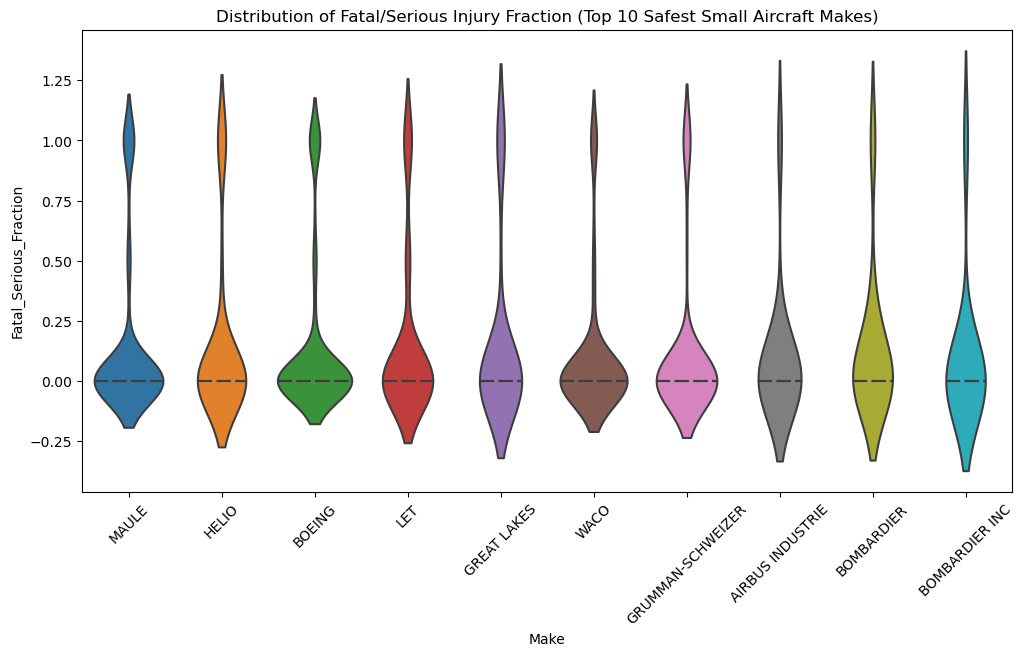

In [30]:
#violi plot
plt.figure(figsize=(12,6))

sns.violinplot(
    data=plot_df,
    x="Make",
    y="Fatal_Serious_Fraction",
    inner="quartile"
)

plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction (Top 10 Safest Small Aircraft Makes)")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [32]:
#filtering large aircraft
large_df = df[df["Aircraft.Size"] == "large"]

In [33]:
#creating safety metric
large_df["Fatal_Serious_Fraction"] = (
    (large_df["Total.Fatal.Injuries"] + large_df["Total.Serious.Injuries"])
    / large_df["Total.People"]
).replace([np.inf, -np.inf], 0).fillna(0)

C:\Users\gmkinuthia\AppData\Local\Temp\ipykernel_20320\2396263690.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  large_df["Fatal_Serious_Fraction"] = (


In [34]:
#top10 safest aircraft
top10_large_makes = large_df.groupby("Make")["Fatal_Serious_Fraction"].mean() \
    .sort_values().head(10).index

In [35]:
#filtering data
plot_large = large_df[large_df["Make"].isin(top10_large_makes)]

C:\Users\gmkinuthia\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gmkinuthia\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


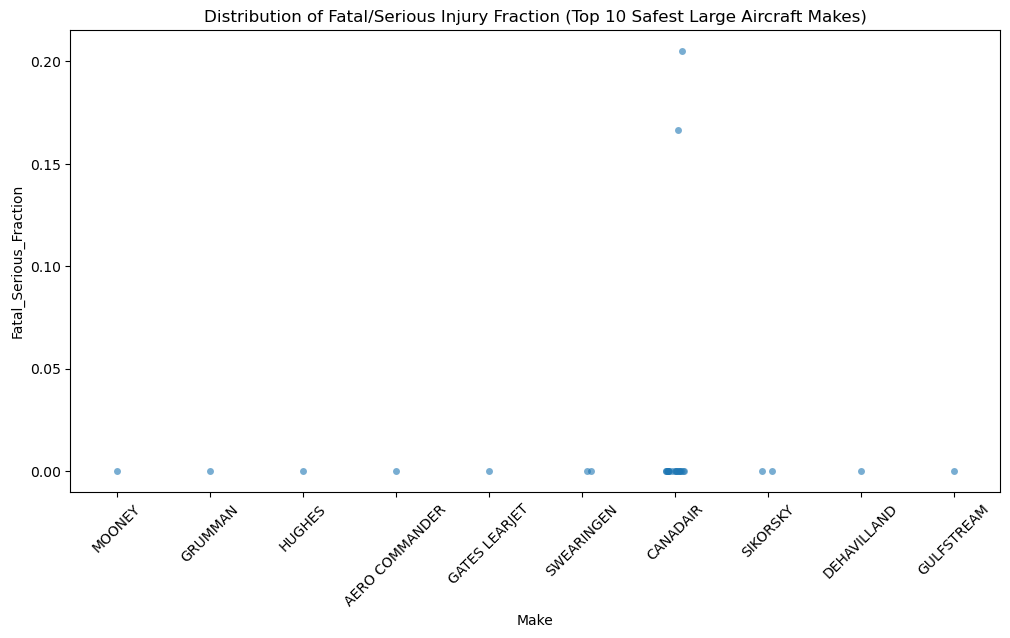

In [36]:
#strip plot 
plt.figure(figsize=(12,6))

sns.stripplot(
    data=plot_large,
    x="Make",
    y="Fatal_Serious_Fraction",
    jitter=True,
    alpha=0.6
)

plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction (Top 10 Safest Large Aircraft Makes)")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [37]:
#ensuring numeric data type
df["Destroyed.Flag"] = df["Destroyed.Flag"].astype(int)

In [40]:
#destruction rate for small aircrafts
small_df = df[df["Aircraft.Size"] == "small"]

small_destroy = small_df.groupby("Make").agg(
    accidents=("Make", "count"),
    destroyed=("Destroyed.Flag", "sum")
)

small_destroy["destruction_rate"] = small_destroy["destroyed"] / small_destroy["accidents"]

small_top15_safe = small_destroy.sort_values("destruction_rate").head(15)
small_top15_safe

,accidents,destroyed,destruction_rate
Make,,,
GRUMMAN ACFT ENG COR-SCHWEIZER,58,1,0.017241
AMERICAN CHAMPION AIRCRAFT,54,2,0.037037
AVIAT AIRCRAFT INC,77,3,0.038961
DEHAVILLAND,100,4,0.040000
BOMBARDIER,21,1,0.047619
DIAMOND AIRCRAFT IND INC,74,4,0.054054
FLIGHT DESIGN GMBH,50,3,0.060000
ROBINSON HELICOPTER,229,14,0.061135
RAVEN,79,5,0.063291


In [41]:
#destruction rate for large aircraft
large_df = df[df["Aircraft.Size"] == "large"]

large_destroy = large_df.groupby("Make").agg(
    accidents=("Make", "count"),
    destroyed=("Destroyed.Flag", "sum")
)

large_destroy["destruction_rate"] = large_destroy["destroyed"] / large_destroy["accidents"]

large_top15_safe = large_destroy.sort_values("destruction_rate").head(15)
large_top15_safe

,accidents,destroyed,destruction_rate
Make,,,
AERO COMMANDER,1,0,0.000000
MOONEY,1,0,0.000000
HUGHES,1,0,0.000000
GULFSTREAM,1,0,0.000000
GRUMMAN,1,0,0.000000
GATES LEARJET,1,0,0.000000
SIKORSKY,2,0,0.000000
DEHAVILLAND,1,0,0.000000
SWEARINGEN,2,0,0.000000


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

To assess aircraft safety, this analysis separated small and large aircraft and focused on two practical outcomes: how often passengers are fatally or seriously injured, and how often aircraft are destroyed during accidents.
For small aircraft, most accidents across the safest manufacturers result in no fatal or serious injuries, which is reflected by distributions that are concentrated near zero. That said, the violin plots also show long upper tails, meaning severe outcomes, while rare, do occur. Makes such as Grumman‑Schweizer, Maule, Waco, Bombardier, and Airbus Industrie stand out because they pair lower average injury fractions with more stable distributions, suggesting safer and more consistent outcomes. This observation is reinforced by the destruction‑rate analysis, where these same manufacturers generally show lower proportions of total aircraft loss, strengthening their overall safety profile.
In contrast, large aircraft display a much clearer pattern. Injury rates are tightly clustered near zero for nearly all of the top manufacturers, with very few outliers. The strip plot reflects this consistency, highlighting the safety advantages of larger aircraft design, redundancy, and standardized operations. Manufacturers including Gulfstream, Bombardier (and Canadair), Airbus‑affiliated makes, Sikorsky, and Boeing combine low fatal/serious injury fractions with low destruction rates, even in cases where the absolute number of accidents is higher.
Size‑specific recommendations. For small aircraft, selecting manufacturers that consistently show lower injury severity and destruction rates can meaningfully reduce risk. For large aircraft, safety outcomes are more uniformly strong across the leading manufacturers.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [42]:
#filtering large aircraft
large = df[df["Aircraft.Size"] == "large"].copy()

In [49]:
#ensure safety metric
large["Fatal_Serious_Fraction"] = (
    (large["Total.Fatal.Injuries"] + large["Total.Serious.Injuries"])
    / large["Total.People"]
).replace([np.inf, -np.inf], 0).fillna(0)

In [50]:
#Make + model aggregation
large_summary = large.groupby(["Make", "Model"]).agg(
    accidents=("Make", "count"),
    injury_risk=("Fatal_Serious_Fraction", "mean"),
    destruction_rate=("Destroyed.Flag", "mean")
).reset_index()

In [51]:
#filter application
large_summary = large_summary[large_summary["accidents"] >= 10]

In [52]:
#safest large aircraft make
large_summary["safety_score"] = (
    large_summary["injury_risk"] +
    large_summary["destruction_rate"]
)
top_large_models = large_summary.sort_values("safety_score").head(15)
top_large_models

,Make,Model,accidents,injury_risk,destruction_rate,safety_score
758,MCDONNELL DOUGLAS,MD-80,15,0.001200,0.0,0.001200
154,BOEING,717-200,15,0.001350,0.0,0.001350
253,BOEING,737-322,12,0.001444,0.0,0.001444
355,BOEING,757-251,10,0.001463,0.0,0.001463
124,AIRBUS INDUSTRIE,A320-232,11,0.002011,0.0,0.002011
333,BOEING,747-422,12,0.002208,0.0,0.002208
281,BOEING,737-7H4,17,0.002721,0.0,0.002721
260,BOEING,737-3H4,10,0.002832,0.0,0.002832
420,BOEING,787,11,0.003058,0.0,0.003058
349,BOEING,757-223,13,0.003098,0.0,0.003098


<Figure size 1000x500 with 0 Axes>

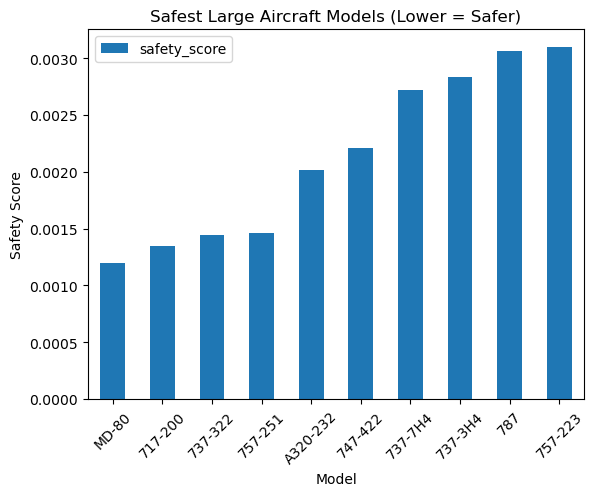

In [53]:
#Safest Large Aircraft Models note : (Lower = Safer)
plt.figure(figsize=(10,5))

top_large_models.sort_values("safety_score").head(10).plot(
    x="Model",
    y="safety_score",
    kind="bar"
)

plt.title("Safest Large Aircraft Models (Lower = Safer)")
plt.ylabel("Safety Score")
plt.xticks(rotation=45)
plt.show()

In [69]:
#top10 safest makes - lowest mean risk)

safe_large_makes = large.groupby("Make")["Fatal_Serious_Fraction"] \
    .mean() \
    .sort_values() \
    .head(10) \
    .index

plot_large = large[large["Make"].isin(safe_large_makes)]

C:\Users\gmkinuthia\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gmkinuthia\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


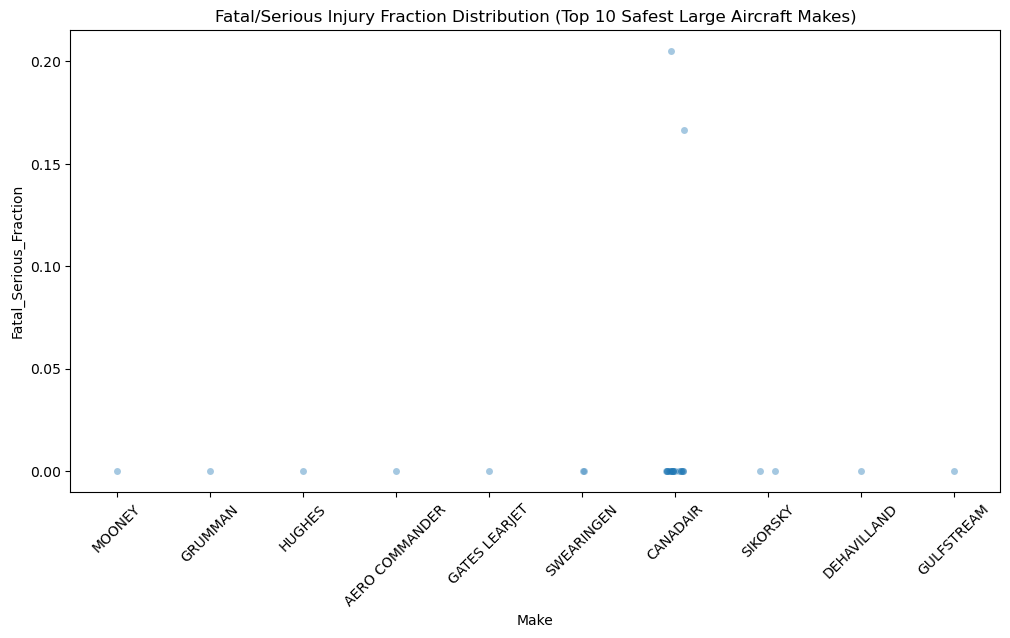

In [70]:
#strip plot distribution
plt.figure(figsize=(12,6))

sns.stripplot(
    data=plot_large,
    x="Make",
    y="Fatal_Serious_Fraction",
    jitter=True,
    alpha=0.4
)

plt.xticks(rotation=45)
plt.title("Fatal/Serious Injury Fraction Distribution (Top 10 Safest Large Aircraft Makes)")
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [54]:
#filtering small aircraft
small = df[df["Aircraft.Size"] == "small"].copy()

In [55]:
#creating safety metrics
small["Fatal_Serious_Fraction"] = (
    (small["Total.Fatal.Injuries"] + small["Total.Serious.Injuries"])
    / small["Total.People"]
).replace([np.inf, -np.inf], 0).fillna(0)

In [56]:
#top10 safest makes by mean injury fraction
safe_makes = small.groupby("Make")["Fatal_Serious_Fraction"].mean() \
    .sort_values().head(10).index

In [58]:
#filtering those makes only
small_filtered = small[small["Make"].isin(safe_makes)]
small_filtered

,Event.Date,year,Make,Model,Aircraft.damage,Number.of.Engines,Engine.Type,Purpose.of.flight,Weather.Condition,Broad.phase.of.flight,...,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Total.People,Serious.Fatal.Injuries,Serious.Fatal.Rate,Destroyed.Flag,Aircraft.Type,Aircraft.Size,Fatal_Serious_Fraction
95,1983-01-15,1983,MAULE,M4-180C,Substantial,1.0,reciprocating,unknown,VMC,descent,...,0.0,0.0,2.0,2.0,0.0,0.000000,0,MAULE M4-180C,small,0.000000
199,1983-02-04,1983,MAULE,M-5-220C,Destroyed,1.0,reciprocating,business,VMC,cruise,...,1.0,3.0,0.0,4.0,1.0,0.250000,1,MAULE M-5-220C,small,0.250000
255,1983-02-12,1983,HELIO,H-395,Substantial,1.0,reciprocating,personal,VMC,landing,...,0.0,0.0,5.0,5.0,0.0,0.000000,0,HELIO H-395,small,0.000000
467,1983-03-12,1983,HELIO,H-295,Substantial,1.0,reciprocating,other work use,VMC,maneuvering,...,0.0,0.0,2.0,2.0,0.0,0.000000,0,HELIO H-295,small,0.000000
537,1983-03-20,1983,BOEING,D75N1,Substantial,1.0,reciprocating,ferry,VMC,cruise,...,0.0,0.0,1.0,1.0,0.0,0.000000,0,BOEING D75N1,small,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70004,2022-10-09,2022,MAULE,MX-7-160,Substantial,1.0,unknown,personal,UNK,unknown,...,1.0,0.0,2.0,3.0,1.0,0.333333,0,MAULE MX-7-160,small,0.333333
70016,2022-10-15,2022,BOEING,A75N1(PT17),Substantial,1.0,unknown,personal,VMC,unknown,...,0.0,0.0,1.0,1.0,0.0,0.000000,0,BOEING A75N1(PT17),small,0.000000
70049,2022-10-26,2022,BOEING,A75N1(PT17),Substantial,1.0,unknown,personal,VMC,unknown,...,0.0,0.0,2.0,2.0,0.0,0.000000,0,BOEING A75N1(PT17),small,0.000000
70063,2022-11-02,2022,MAULE,M-7-235B,Substantial,1.0,unknown,personal,VMC,unknown,...,0.0,0.0,1.0,1.0,0.0,0.000000,0,MAULE M-7-235B,small,0.000000


In [59]:
#make + model aggregation (safety and destruction)
small_summary = small_filtered.groupby(["Make", "Model"]).agg(
    accidents=("Make", "count"),
    injury_risk=("Fatal_Serious_Fraction", "mean"),
    destruction_rate=("Destroyed.Flag", "mean")
).reset_index()

In [60]:
#we keep our interest on 10 observations
small_summary = small_summary[small_summary["accidents"] >= 10]

In [61]:
#overall safety score
small_summary["safety_score"] = (
    small_summary["injury_risk"] +
    small_summary["destruction_rate"]
)

In [62]:
#ranking safest small aircraft models
top_small_models = small_summary.sort_values("safety_score").head(15)
top_small_models

,Make,Model,accidents,injury_risk,destruction_rate,safety_score
425,MAULE,MX-7-235,17,0.029412,0.000000,0.029412
371,MAULE,M-7-235B,10,0.050000,0.000000,0.050000
419,MAULE,MX-7-180,10,0.100000,0.000000,0.100000
344,MAULE,M-4,18,0.055556,0.055556,0.111111
426,MAULE,MX7,18,0.125000,0.000000,0.125000
76,BOEING,747,30,0.066667,0.066667,0.133333
305,LET,BLANIK L-13,21,0.095238,0.047619,0.142857
157,BOEING,A75N1(PT17),32,0.135417,0.031250,0.166667
312,LET,L-13,48,0.114583,0.062500,0.177083
54,BOEING,737,45,0.133333,0.044444,0.177778


<Figure size 1000x500 with 0 Axes>

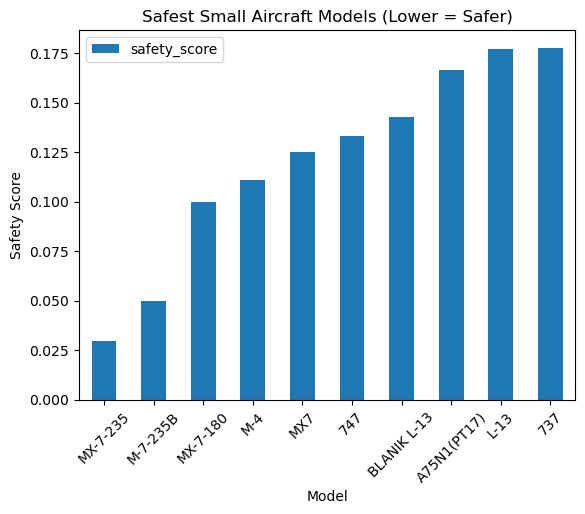

In [63]:
#safest small aircraft models - note - lower = safer
plt.figure(figsize=(10,5))

top_small_models.sort_values("safety_score").head(10).plot(
    x="Model",
    y="safety_score",
    kind="bar"
)

plt.title("Safest Small Aircraft Models (Lower = Safer)")
plt.ylabel("Safety Score")
plt.xticks(rotation=45)
plt.show()

In [65]:
#safest 10 makes 
safe_makes = small.groupby("Make")["Fatal_Serious_Fraction"].mean() \
    .sort_values().head(10).index

plot_data = small[small["Make"].isin(safe_makes)]

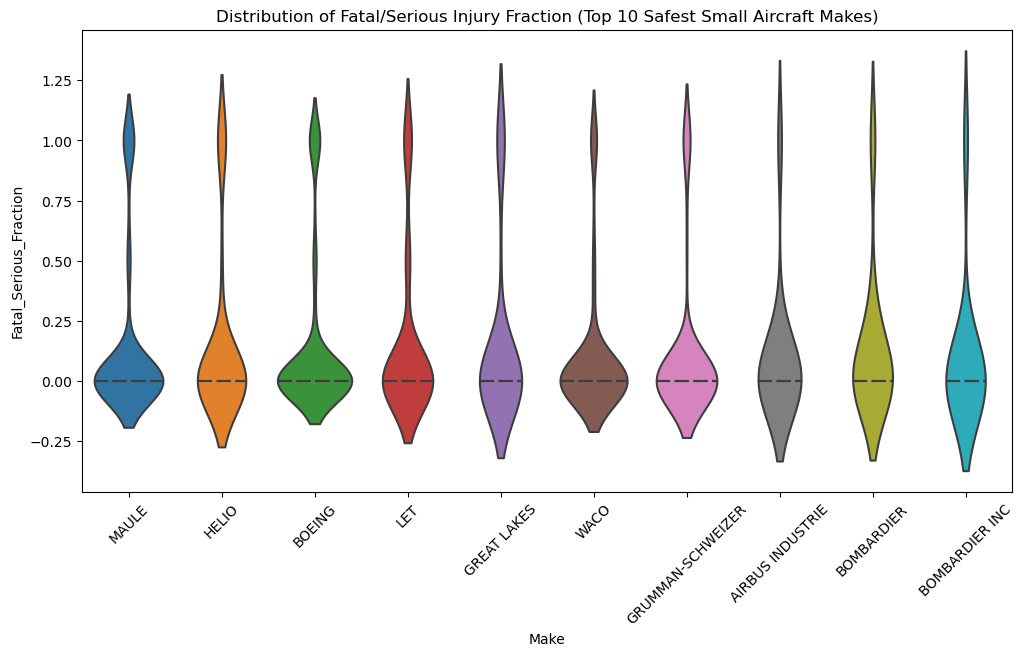

In [66]:
#violin plot
plt.figure(figsize=(12,6))

sns.violinplot(
    data=plot_data,
    x="Make",
    y="Fatal_Serious_Fraction",
    inner="quartile"
)

plt.xticks(rotation=45)
plt.title("Distribution of Fatal/Serious Injury Fraction (Top 10 Safest Small Aircraft Makes)")
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

For large aircraft models, injury fractions are consistently very close to zero across the safest models, with little variation in the distribution. Models such as the MD‑80, Boeing 717/737/757 series, and Airbus A320 family show low average injury risk and minimal dispersion in the plots, indicating both strong and stable passenger safety performance. These results suggest that, at the model level, large aircraft generally provide reliable protection to occupants, even when accidents occur.
In contrast, small aircraft models display greater variability in passenger injury outcomes. While many incidents still result in no fatal or serious injuries, the distributions show longer upper tails, reflecting occasional high‑severity events. Certain models—particularly those from Maule, along with select LET and legacy Boeing models—perform relatively better, combining lower mean injury fractions with fewer destroyed aircraft. However, compared to large aircraft, safety outcomes for small aircraft models are less uniform, making model selection more critical in reducing passenger risk.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

1. EXPLORING FACTORS AFFECTING AIRCRAFT DAMAGE & INJURY BY ANALYZING WEATHER CONDITION AND PHASE OF FLIGHT

1.1 WEATHER CONDITION vs SAFETY

In [71]:
#cleaning the metric
df["Fatal_Serious_Fraction"] = (
    (df["Total.Fatal.Injuries"] + df["Total.Serious.Injuries"])
    / df["Total.People"]
).replace([np.inf, -np.inf], 0).fillna(0)

In [72]:
#comparing average injury risk acrss weather types
weather_summary = df.groupby("Weather.Condition").agg(
    mean_injury_risk=("Fatal_Serious_Fraction", "mean"),
    mean_destroyed=("Destroyed.Flag", "mean"),
    count=("Weather.Condition", "count")
).reset_index()

weather_summary

,Weather.Condition,mean_injury_risk,mean_destroyed,count
0,IMC,0.641267,0.564219,5271
1,UNK,0.487679,0.321027,3738
2,VMC,0.225384,0.168038,61153


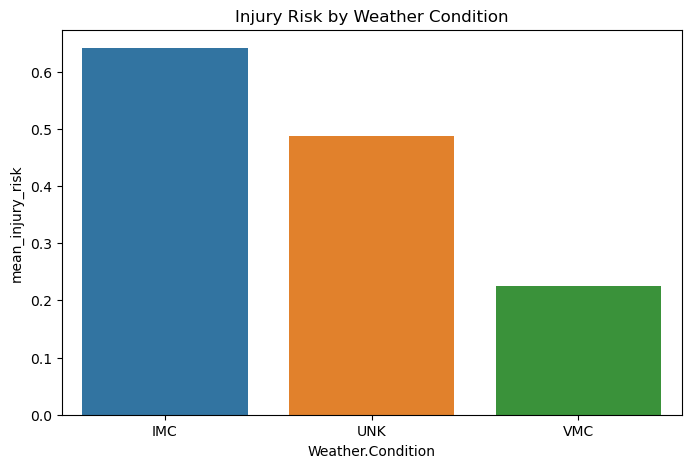

In [73]:
#visualization 
plt.figure(figsize=(8,5))

sns.barplot(
    data=weather_summary,
    x="Weather.Condition",
    y="mean_injury_risk"
)

plt.title("Injury Risk by Weather Condition")
plt.show()

IMC shows higher injury risk than VMC.
Infact, reduced visibility increases:
    navigation errors.
    approach/landing accidents.
UNK values likely inflate uncertainty but trend remains consistent
Overall, poor visibility conditions significantly increase severity of accidents, confirming weather as a major operational risk factor in the aviation industry

In [ ]:
1.2 PHASE OF FLIGHT vs SAFETY

In [74]:
#injury risk against phase of flight
phase_summary = df.groupby("Broad.phase.of.flight").agg(
    mean_injury_risk=("Fatal_Serious_Fraction", "mean"),
    mean_destroyed=("Destroyed.Flag", "mean"),
    count=("Broad.phase.of.flight", "count")
).reset_index()

phase_summary

,Broad.phase.of.flight,mean_injury_risk,mean_destroyed,count
0,approach,0.335912,0.284301,5255
1,climb,0.387920,0.382583,1665
2,cruise,0.340362,0.329709,8462
3,descent,0.304263,0.288620,1573
4,go-around,0.298581,0.288591,1192
5,landing,0.040815,0.045104,13103
6,maneuvering,0.467466,0.422404,6347
7,other,0.364543,0.289157,83
8,standing,0.138331,0.105072,828
9,takeoff,0.225425,0.217347,9869


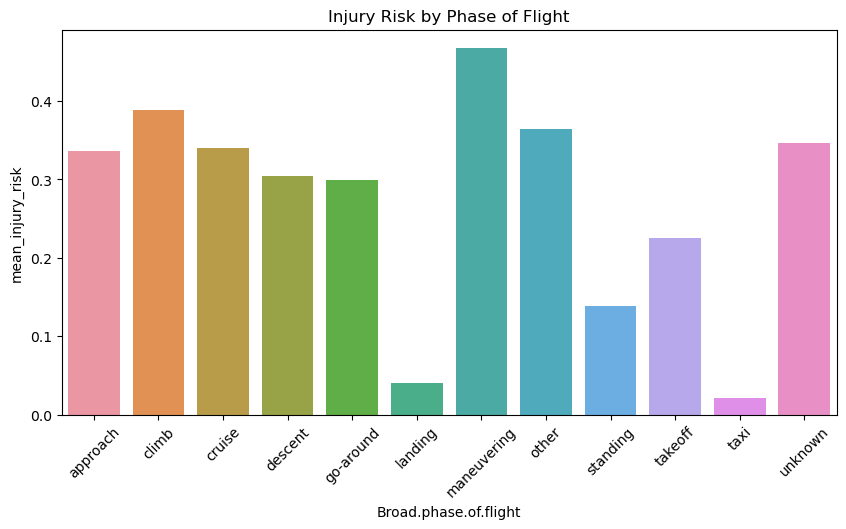

In [76]:
#visualization plot
plt.figure(figsize=(10,5))

sns.barplot(
    data=phase_summary,
    x="Broad.phase.of.flight",
    y="mean_injury_risk"
)

plt.xticks(rotation=45)
plt.title("Injury Risk by Phase of Flight")
plt.show()

Highest-risk phases
Maneuvering (0.47) is the highest-risk phase overall. followed by Climb (0.39),Other (0.36),Unknown (0.35),Approach (0.34). These phases involve high workload, rapid configuration changes, or non-standard flight conditions
Moderate-risk phases
Moderate risk phases include Cruise (0.34),Descent (0.30),Go-around (0.30). These are generally more stable phases, but still involve transition or altitude change
Lowest-risk phases
Taxi (0.02) — lowest risk overall
Landing (0.04)
Standing (0.14)
Takeoff (0.23)
Surprisingly, landing shows very low average fatal/serious injury fraction in this dataset, likely because many landing incidents involve non-fatal runway events

Overall, accident severity is strongly phase-dependent, with maneuvering and climb phases showing the highest likelihood of serious or fatal injuries. In contrast, ground operations e.g taxi and standing present minimal injury risk, highlighting that most severe safety risks arise during active flight transitions rather than stable operations.
